In [3]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.processing import WESADDataset

In [4]:
# Load and filter subject S2
loader = WESADDataset('../data/WESAD')
df_raw = loader.load_subject('S2')
df = loader.filter_target_states(df_raw)

# Separate baseline and stress for easy comparison
baseline = df[df['Label'] == 0]
stress   = df[df['Label'] == 1]

print(f"Baseline samples: {len(baseline):,}")
print(f"Stress samples:   {len(stress):,}")

Loading S2 data... This might take a moment.
Baseline samples: 800,800
Stress samples:   430,500


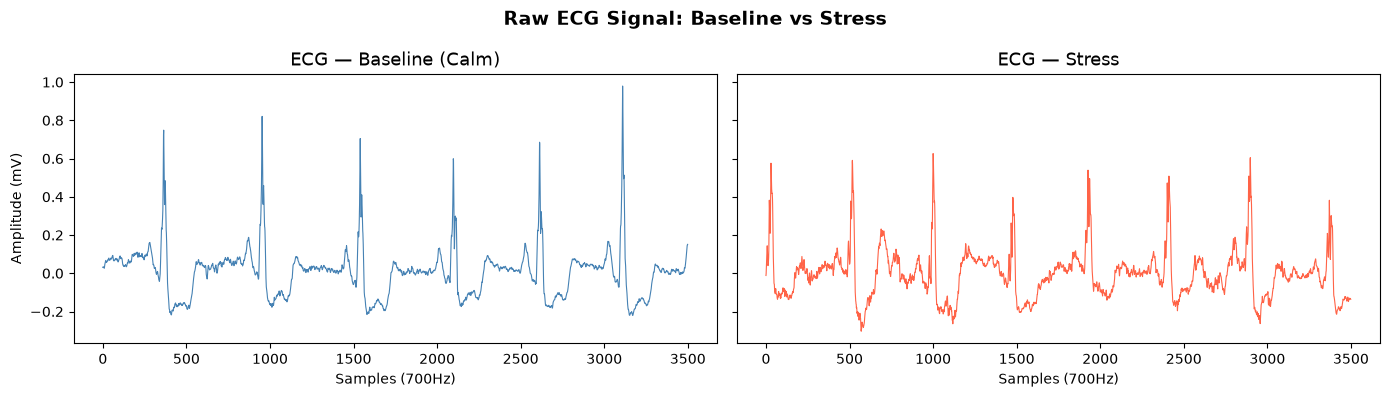

In [6]:
# Take 5 seconds (3500 samples) from each condition
duration = 5 * 700  # 5 seconds at 700Hz

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(baseline['ECG'].values[:duration], color='steelblue', linewidth=0.8)
axes[0].set_title('ECG — Baseline (Calm)', fontsize=13)
axes[0].set_xlabel('Samples (700Hz)')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(stress['ECG'].values[:duration], color='tomato', linewidth=0.8)
axes[1].set_title('ECG — Stress', fontsize=13)
axes[1].set_xlabel('Samples (700Hz)')

plt.suptitle('Raw ECG Signal: Baseline vs Stress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/ecg_comparison.png', dpi=150)
plt.show()